# Reproducible Evaluation of Phishing URL Detection

This notebook reproduces and critically evaluates the public
[Phishing-URL-Detection](https://github.com/vaibhavbichave/Phishing-URL-Detection)
project. It is designed to run from the repository root without Colab-specific
paths.

**Research question.** How reliably do a linear baseline and a nonlinear
ensemble distinguish phishing from legitimate websites on the supplied
engineered-feature dataset?

**Security convention.** Phishing is encoded as the positive class (`1`). A
false negative therefore means a phishing sample was predicted legitimate -
the higher-risk operational error.

## 1. Reproducible setup

Randomness is fixed at 42. Preprocessing is fitted inside each pipeline, which
prevents information from the test or validation fold from influencing the
training transformation.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, precision_recall_curve

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

# Resolve the project from either the repository root or notebooks/.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "phishing.csv").is_file():
    ROOT = ROOT.parent
if not (ROOT / "data" / "phishing.csv").is_file():
    raise FileNotFoundError("Run from the repository root or a child directory")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis import (
    build_models,
    cross_validation_summary,
    feature_groups,
    grouped_split,
    holdout_metrics,
    load_dataset,
    out_of_fold_threshold_selection,
    prepare_data,
    split_data,
)

## 2. Data provenance and validation

The CSV was obtained from the evaluated GitHub repository. The upstream
project does not fully document collection dates, URL sources, or the labeling
process. These omissions are threats to external validity and are revisited in
the limitations section.

In [2]:
df = load_dataset(ROOT)
profile = pd.Series({
    "rows": len(df),
    "columns_including_target": df.shape[1],
    "missing_values": int(df.isna().sum().sum()),
    "exact_duplicate_rows": int(df.duplicated().sum()),
    "duplicates_excluding_Index": int(df.drop(columns=["Index"]).duplicated().sum()),
    "duplicate_feature_rows": int(df.duplicated(subset=[c for c in df.columns if c not in {"Index", "class"}]).sum()),
}, name="value")
display(profile.to_frame())
display(df.head())
display(df["class"].value_counts().rename(index={-1: "phishing (-1)", 1: "legitimate (1)"}).to_frame("count"))

,value
rows,11054
columns_including_target,32
missing_values,0
exact_duplicate_rows,0
duplicates_excluding_Index,5205
duplicate_feature_rows,5269


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


,count
class,
legitimate (1),6157
phishing (-1),4897


The `Index` column is a row identifier,
not a behavioral property of a URL. It is retained for tracing errors but
excluded from predictors. Thousands of samples share an identical feature
vector, and some identical vectors have conflicting labels. All later splits
therefore keep an exact-match feature group wholly within one fold to prevent
duplicate leakage.

## 3. Exploratory analysis

,value
unique_feature_vectors,5785
rows_beyond_first_in_group,5269
groups_with_conflicting_labels,64


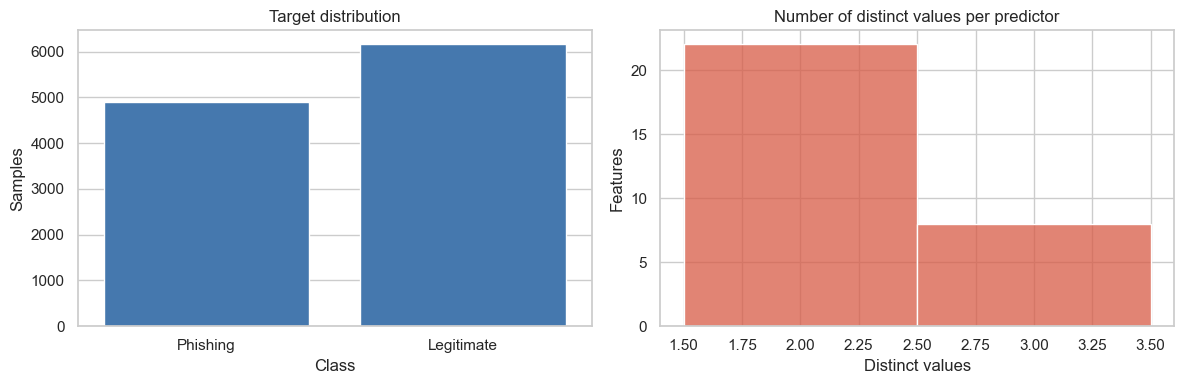

Predictors after identifier removal: 30


,distinct-value count
count,30.000000
mean,2.266667
std,0.449776
min,2.000000
25%,2.000000
50%,2.000000
75%,2.750000
max,3.000000


In [3]:
X, y, row_ids = prepare_data(df)
groups = feature_groups(X)
group_labels = pd.DataFrame({"group": groups, "target": y}).groupby("group")["target"]
group_summary = pd.Series({
    "unique_feature_vectors": groups.nunique(),
    "rows_beyond_first_in_group": len(groups) - groups.nunique(),
    "groups_with_conflicting_labels": int(group_labels.nunique().gt(1).sum()),
}, name="value")
display(group_summary.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y.map({0: "Legitimate", 1: "Phishing"}), ax=axes[0], color="#3478bf")
axes[0].set(title="Target distribution", xlabel="Class", ylabel="Samples")

feature_counts = X.nunique().sort_values()
sns.histplot(feature_counts, discrete=True, ax=axes[1], color="#d85b45")
axes[1].set(title="Number of distinct values per predictor", xlabel="Distinct values", ylabel="Features")
plt.tight_layout()
plt.show()

print(f"Predictors after identifier removal: {X.shape[1]}")
display(feature_counts.describe().to_frame("distinct-value count"))

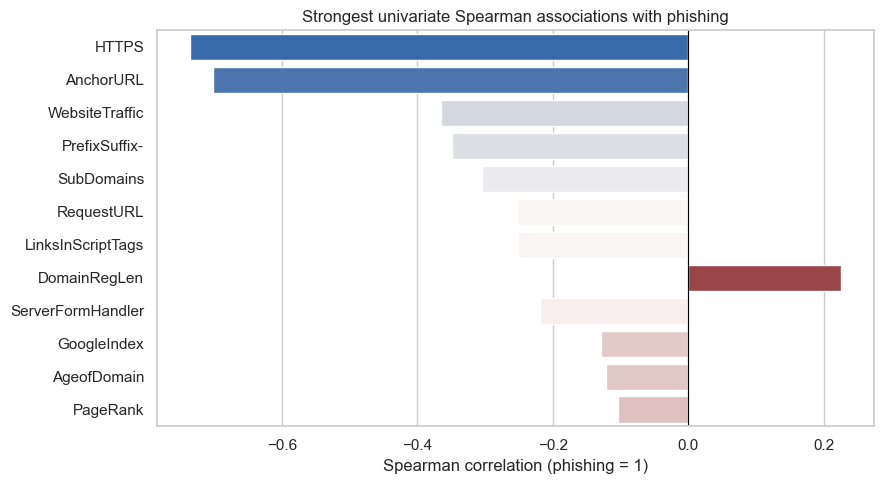

,spearman_rho
HTTPS,-0.735788
AnchorURL,-0.701160
WebsiteTraffic,-0.365033
PrefixSuffix-,-0.348588
SubDomains,-0.304612
RequestURL,-0.253478
LinksInScriptTags,-0.250893
DomainRegLen,0.225879
ServerFormHandler,-0.219150
GoogleIndex,-0.129000


In [4]:
correlations = X.apply(lambda column: column.corr(y, method="spearman"))
top_correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).head(12).index)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_correlations.values, y=top_correlations.index, hue=top_correlations.values,
            palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Strongest univariate Spearman associations with phishing")
plt.xlabel("Spearman correlation (phishing = 1)")
plt.ylabel("")
plt.tight_layout()
plt.show()
display(top_correlations.rename("spearman_rho").to_frame())

Correlation is descriptive, not causal.
Several indicators may be derived from related signals, and the source does
not document whether all features would be available at decision time in a
real deployment.

## 4. Experimental design

The fixed stratified, group-aware 80/20 split creates a development partition
and an untouched final test partition. Five-fold stratified group
cross-validation on the development data selects the model and measures split
sensitivity. Identical predictor vectors cannot cross a boundary. The test
partition is used once, after the model and threshold have both been fixed.
The reported 95% intervals are normal approximations over five folds; with so
few folds, they summarize variability rather than provide a definitive
population-level confidence guarantee.

In [5]:
X_development, X_test, y_development, y_test, groups_development, groups_test = grouped_split(X, y, groups)
models = build_models(X.columns.tolist())

split_summary = pd.DataFrame({
    "partition": ["development", "untouched final test"],
    "rows": [len(X_development), len(X_test)],
    "phishing_rate": [y_development.mean(), y_test.mean()],
})
display(split_summary)

,partition,rows,phishing_rate
0,development,8827,0.441713
1,untouched final test,2227,0.448137


## 5. Development cross-validation and model selection

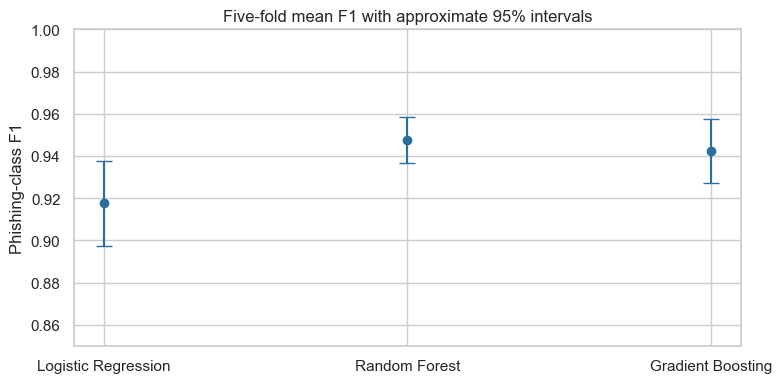

Selected model by development CV F1: Random Forest


In [6]:
assert set(groups_development).isdisjoint(set(groups_test))
cv_results = cross_validation_summary(models, X_development, y_development, groups_development)
cv_table = cv_results.pivot(index="metric", columns="model", values=["mean", "std", "ci95_low", "ci95_high"])
display(cv_table.style.format("{:.4f}"))

cv_f1 = cv_results.loc[cv_results["metric"].eq("f1")].copy()
best_name = cv_f1.sort_values("mean", ascending=False).iloc[0]["model"]
selected_model = clone(models[best_name])

plt.figure(figsize=(8, 4))
errors = np.vstack([cv_f1["mean"] - cv_f1["ci95_low"], cv_f1["ci95_high"] - cv_f1["mean"]])
plt.errorbar(cv_f1["model"], cv_f1["mean"], yerr=errors, fmt="o", capsize=6, color="#2b6f9f")
plt.ylim(0.85, 1.0)
plt.ylabel("Phishing-class F1")
plt.title("Five-fold mean F1 with approximate 95% intervals")
plt.tight_layout()
plt.show()
print(f"Selected model by development CV F1: {best_name}")

## 6. Out-of-fold threshold selection

The decision threshold is selected from out-of-fold development probabilities,
never from the final test set. The security-oriented rule maximizes phishing
recall subject to at least 95% phishing precision. This constraint is an
explicit modeling choice and should ultimately be set from organizational
costs rather than treated as universally optimal.

,threshold,phishing_precision,phishing_recall,f1,missed_phishing,blocked_legitimate
0,0.20,0.8536,0.9903,0.9169,38,662
1,0.25,0.8739,0.9828,0.9252,67,553
2,0.30,0.8990,0.9769,0.9363,90,428
3,0.35,0.9129,0.9674,0.9394,127,360
4,0.40,0.9258,0.9595,0.9423,158,300
5,0.45,0.9374,0.9531,0.9452,183,248
6,0.50,0.9498,0.9454,0.9476,213,195
7,0.55,0.9576,0.9392,0.9483,237,162
8,0.60,0.9670,0.9238,0.9449,297,123
9,0.65,0.9740,0.9136,0.9428,337,95


Selected threshold: 0.55
Rule: maximum out-of-fold phishing recall with precision >= 0.95


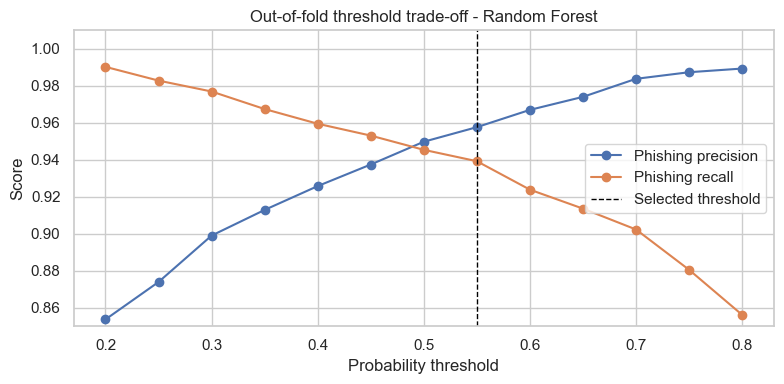

In [7]:
threshold_table, selected_threshold, threshold_rule, development_prob = out_of_fold_threshold_selection(
    selected_model, X_development, y_development, precision_floor=0.95, groups=groups_development
)
display(threshold_table.style.format({
    "threshold": "{:.2f}", "phishing_precision": "{:.4f}",
    "phishing_recall": "{:.4f}", "f1": "{:.4f}"
}))
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"Rule: {threshold_rule}")

plt.figure(figsize=(8, 4))
plt.plot(threshold_table["threshold"], threshold_table["phishing_precision"], marker="o", label="Phishing precision")
plt.plot(threshold_table["threshold"], threshold_table["phishing_recall"], marker="o", label="Phishing recall")
plt.axvline(selected_threshold, color="black", linestyle="--", linewidth=1, label="Selected threshold")
plt.xlabel("Probability threshold")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.title(f"Out-of-fold threshold trade-off - {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Final untouched test evaluation

,threshold,accuracy,phishing_precision,phishing_recall,f1,mcc,roc_auc
model,,,,,,,
Random Forest,0.5500,0.9416,0.9493,0.9188,0.9338,0.8820,0.9889


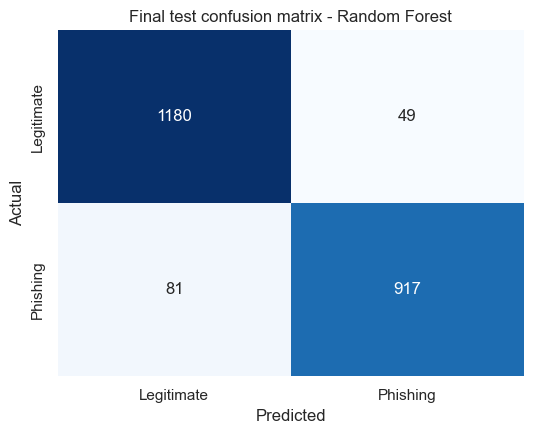

In [8]:
final_model = clone(selected_model).fit(X_development, y_development)
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)
final_results = pd.DataFrame([{
    "model": best_name,
    "threshold": selected_threshold,
    **holdout_metrics(y_test, test_prediction, test_probability),
}]).set_index("model")
display(final_results.style.format("{:.4f}"))

matrix = confusion_matrix(y_test, test_prediction, labels=[0, 1])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Legitimate", "Phishing"], yticklabels=["Legitimate", "Phishing"])
plt.title(f"Final test confusion matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Model interpretation

Tree-based impurity importance is useful for screening but can favor features
with more possible split points and does not establish causality. The plot is
therefore interpreted as model behavior, not as a definitive list of phishing
causes.

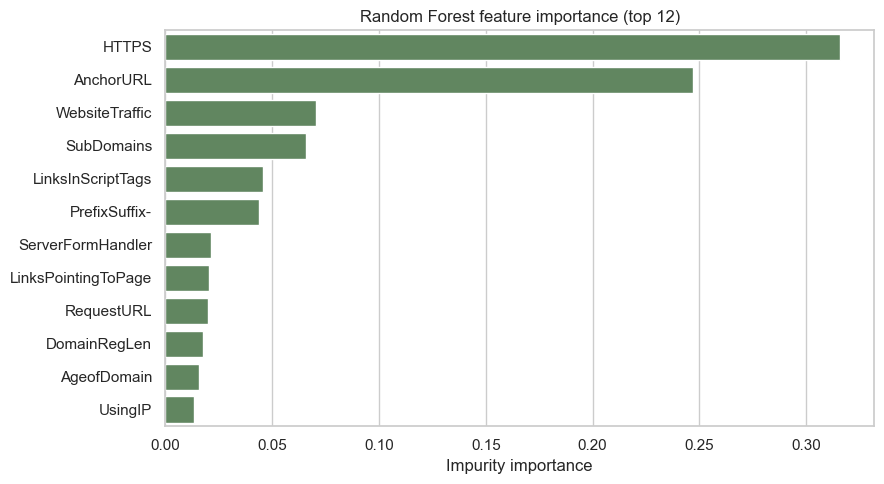

,importance
HTTPS,0.315943
AnchorURL,0.247080
WebsiteTraffic,0.070555
SubDomains,0.065580
LinksInScriptTags,0.045456
PrefixSuffix-,0.043652
ServerFormHandler,0.021109
LinksPointingToPage,0.020596
RequestURL,0.019708
DomainRegLen,0.017446


In [9]:
fitted_estimator = final_model.named_steps["model"]
if hasattr(fitted_estimator, "feature_importances_"):
    raw_importance = fitted_estimator.feature_importances_
    importance_label = "Impurity importance"
else:
    raw_importance = np.abs(fitted_estimator.coef_[0])
    importance_label = "Absolute standardized coefficient"
importance = pd.Series(raw_importance, index=X.columns, name="importance").sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.head(12).values, y=importance.head(12).index, color="#5b8c5a")
plt.title(f"{best_name} feature importance (top 12)")
plt.xlabel(importance_label)
plt.ylabel("")
plt.tight_layout()
plt.show()
display(importance.head(12).to_frame())

## 9. Security error analysis

Because phishing is the positive class, false negatives are phishing samples
predicted legitimate. They represent the more dangerous security failure.
False positives are legitimate samples blocked as phishing and primarily
represent usability and business-continuity costs.

In [10]:
error_rows = X_test.copy()
error_rows.insert(0, "row_id", row_ids.loc[X_test.index].values)
error_rows["actual"] = y_test.values
error_rows["predicted"] = test_prediction
error_rows["error_type"] = np.select(
    [(error_rows["actual"] == 1) & (error_rows["predicted"] == 0),
     (error_rows["actual"] == 0) & (error_rows["predicted"] == 1)],
    ["False negative: missed phishing", "False positive: legitimate blocked"],
    default="Correct",
)

display(error_rows["error_type"].value_counts().to_frame("count"))
display(error_rows.loc[error_rows["error_type"].ne("Correct")].head(10))

,count
error_type,
Correct,2097
False negative: missed phishing,81
False positive: legitimate blocked,49


,row_id,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,actual,predicted,error_type
8,8,1,1,-1,1,1,-1,-1,1,-1,...,1,-1,0,-1,1,0,1,1,0,False negative: missed phishing
15,15,1,-1,-1,1,1,-1,1,1,-1,...,1,-1,0,-1,1,1,-1,1,0,False negative: missed phishing
184,184,1,-1,1,1,1,-1,-1,1,-1,...,-1,1,0,-1,1,0,1,1,0,False negative: missed phishing
211,211,1,-1,1,1,1,-1,-1,-1,1,...,-1,1,1,-1,1,0,1,0,1,False positive: legitimate blocked
245,245,1,1,1,1,1,-1,1,1,-1,...,1,-1,0,-1,1,1,1,1,0,False negative: missed phishing
284,284,1,-1,1,1,1,-1,-1,1,-1,...,-1,1,0,-1,1,0,1,1,0,False negative: missed phishing
354,354,1,-1,1,1,1,-1,1,1,-1,...,1,-1,0,-1,1,1,1,1,0,False negative: missed phishing
408,408,1,-1,1,1,1,-1,1,1,-1,...,1,1,0,-1,1,0,1,0,1,False positive: legitimate blocked
566,566,1,-1,1,1,1,-1,0,-1,1,...,-1,1,1,-1,1,0,1,0,1,False positive: legitimate blocked
618,618,1,-1,1,1,1,-1,1,1,-1,...,1,1,0,-1,1,0,1,0,1,False positive: legitimate blocked


## 10. Reproducible result artifacts

The compact result tables are exported under `reports/` so reviewers can audit
the numerical claims without scraping notebook output.

In [11]:
reports_dir = ROOT / "reports"
reports_dir.mkdir(exist_ok=True)
cv_results.to_csv(reports_dir / "cross_validation_results.csv", index=False)
threshold_table.to_csv(reports_dir / "threshold_tuning.csv", index=False)
importance.rename_axis("feature").reset_index().to_csv(reports_dir / "feature_importance.csv", index=False)

tn, fp, fn, tp = matrix.ravel()
export_result = final_results.reset_index().assign(
    true_negative=int(tn), legitimate_blocked_fp=int(fp),
    missed_phishing_fn=int(fn), true_positive=int(tp),
)
export_result.to_csv(reports_dir / "final_test_results.csv", index=False)
print("Saved:")
for path in sorted(reports_dir.glob("*.csv")):
    print(f"- {path.relative_to(ROOT)}")

Saved:
- reports\cross_validation_results.csv
- reports\feature_importance.csv
- reports\final_test_results.csv
- reports\threshold_tuning.csv


## 11. Critical evaluation and threats to validity

### What the experiment supports

- All tested models separate the supplied classes well under random stratified
  evaluation; the nonlinear ensemble performs better than the linear baseline.
- Cross-validation makes the result less dependent on one favorable split.
- Explicit phishing-positive metrics make the security meaning of errors clear.

### What it does not support

- **Temporal generalization:** no timestamps permit train-past/test-future
  evaluation, so concept drift is unmeasured.
- **Dataset representativeness:** the upstream documentation does not establish
  how URLs were sampled, dated, deduplicated, or labeled.
- **Deployment feasibility:** the data contains engineered indicators, not raw
  URLs; latency, feature availability, and collection failures are untested.
- **Adversarial robustness:** attackers may deliberately manipulate URL and
  website signals after learning detector behavior.
- **Probability quality:** high ROC-AUC does not imply calibrated probabilities.

### Methodological extensions

A stronger deployment study would use temporally separated and freshly labeled
URLs, group related domains to prevent cross-split contamination, audit feature
collection at decision time, calibrate probabilities on a validation period,
select thresholds from stated security costs, and monitor post-deployment drift.

## Conclusion

The experiment is a reproducible benchmark, not a production-readiness claim.
Its strongest contribution is the transparent alignment of code, label
semantics, leakage control, evaluation design, and cybersecurity error costs.
Random Forest is the strongest of the three tested models on this dataset, but the absence of
temporal and provenance evidence remains the dominant limitation.

## References

1. V. Bichave, *Phishing-URL-Detection*, GitHub repository,
   https://github.com/vaibhavbichave/Phishing-URL-Detection (accessed 2026-06-28).
2. D. M. W. Powers, "Evaluation: From Precision, Recall and F-Measure to ROC,
   Informedness, Markedness and Correlation," *Journal of Machine Learning
   Technologies*, 2011.
3. D. Chicco and G. Jurman, "The advantages of the Matthews correlation
   coefficient over F1 score and accuracy in binary classification evaluation,"
   *BMC Genomics*, 2020, doi:10.1186/s12864-019-6413-7.
4. F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *Journal of
   Machine Learning Research*, 2011.